In [1]:
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from spectrumlab.peaks.analyte_peaks.intensity.transformers import (
    AmplitudeKernel,
    IntegralKernel,
    RegressionIntensityTransformer,
    estimate_bounds,
    process_frame,
)
from spectrumlab.types import Array, R

from plugin.config import PLUGIN_CONFIG
from plugin.managers.data_source_manager import DataSourceManager
from plugin.managers.data_source_manager.data_sources import XMLDataSource


In [2]:
atom_data = DataSourceManager(
    data_source=XMLDataSource(
        xml='<input>{filepath}</input>'.format(
            filepath=PLUGIN_CONFIG.filepath,
        ),
    ),
).load()

column_id, datum = next(iter(atom_data.data.items()))
datum.nickname

frame = datum.frame.copy()
data = process_frame(frame)
bounds = estimate_bounds(data, threshold=.05)

amplitude_transformer = RegressionIntensityTransformer(
    kernel=AmplitudeKernel(
        intensity=data['intensity'].to_numpy(),
        concentration=data['concentration'].to_numpy(),
        bounds=bounds,
    ),
)
integral_transformer = RegressionIntensityTransformer(
    kernel=IntegralKernel(
        intensity=data['intensity'].to_numpy(),
        concentration=data['concentration'].to_numpy(),
        value=frame['value'],
        bounds=bounds,
        n=10,
        alpha=1e-4,
    ),
)

In [3]:
def calculate_intensity(
    value: Array[R],
    transformer: RegressionIntensityTransformer | None = None,
) -> R:
    
    if transformer is None:
        return np.sum(value)

    return np.sum(transformer.predict(value))


In [4]:
frame = datum.frame.copy()
frame['intensity'] = frame['value'].map(partial(calculate_intensity, transformer=None))
frame['intensity_hat_amplitude'] = frame['value'].map(partial(calculate_intensity, transformer=amplitude_transformer))
frame['intensity_hat_integral'] = frame['value'].map(partial(calculate_intensity, transformer=integral_transformer))

frame[['concentration', 'intensity', 'intensity_hat_amplitude', 'intensity_hat_integral']].groupby(level=0, sort=False).mean().head(50)


,concentration,intensity,intensity_hat_amplitude,intensity_hat_integral
probe_name,,,,
СО 11 ЭЛ 13,0.93,1.413617,1.413617,1.413617
СО 11 ЭЛ 12,1.86,2.334857,2.335796,2.335511
СО 11 ЭЛ 11,3.72,4.446626,4.703544,5.044740
СО 11 ЭЛ 10,7.45,8.200352,9.409872,10.536745
СО 11 ЭЛ 9,14.90,14.884218,19.012849,20.904781
СО 11 ЭЛ 8,29.80,26.947633,39.524878,39.816370
СО 11 ЭЛ 6,59.60,44.543248,80.522530,82.535935
СО 11 ЭЛ 5,119.20,68.113133,160.549227,163.861598
СО 11 ЭЛ 4,238.41,100.566786,279.963350,328.598644


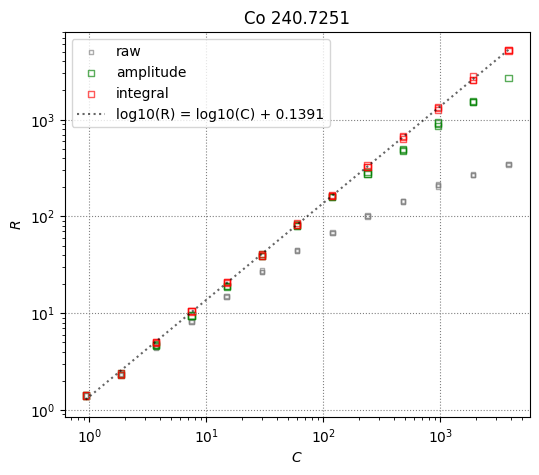

In [5]:
plt.figure(figsize=(6, 5))

plt.scatter(
    frame['concentration'],
    frame['intensity'],
    marker='s', facecolors='none', edgecolors='grey', s=10,
    alpha=.65,
    label='raw',
)
plt.scatter(
    frame['concentration'],
    frame['intensity_hat_amplitude'],
    s=20,
    marker='s',
    facecolors='none',
    edgecolors='green',
    alpha=.65,
    label='amplitude',
)
plt.scatter(
    frame['concentration'],
    frame['intensity_hat_integral'],
    s=20,
    marker='s',
    facecolors='none',
    edgecolors='red',
    alpha=.65,
    label='integral',
)

bias = np.mean(np.log10(frame['intensity_hat_integral']) - np.log10(frame['concentration']))
x = np.linspace(np.log10(frame['concentration']).min(), np.log10(frame['concentration']).max(), 200)
plt.plot(
    10**x,
    10**(x + bias),
    color='black',
    linestyle=':',
    alpha=.6,
    label='log10(R) = log10(C) + {b:.4f}'.format(b=bias),
)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$C$')
plt.ylabel(r'$R$')
plt.title(datum.nickname)
plt.grid(color='grey', linestyle=':')
plt.legend()
plt.show()


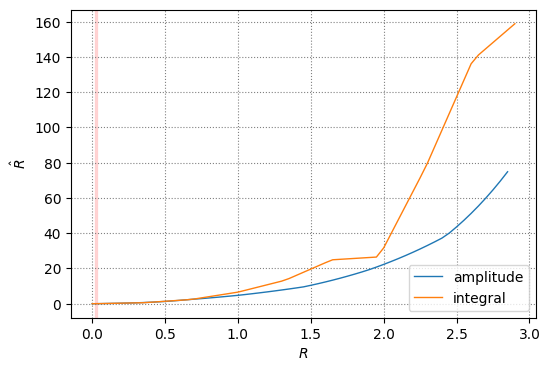

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))

x = np.linspace(0, 5, 101)
plt.plot(
    x,
    amplitude_transformer.predict(x),
    linestyle='-', linewidth=1,
    label='amplitude',
)
plt.plot(
    x,
    integral_transformer.predict(x),
    linestyle='-', linewidth=1,
    label='integral',
)
plt.axvspan(
    *bounds,
    alpha=.125, color='red',
)

# plt.xscale('log')
# plt.yscale('log')
plt.xlabel(r'$R$')
plt.ylabel(r'$\hat{R}$')
plt.grid(color='grey', linestyle=':')
plt.legend()
plt.show()

In [7]:
pd.concat([
    frame['concentration'].groupby(level=0, sort=False).mean(),
    100 * frame[['intensity_hat_amplitude', 'intensity_hat_integral']].groupby(level=0, sort=False).std(ddof=1) / \
    frame[['intensity_hat_amplitude', 'intensity_hat_integral']].groupby(level=0, sort=False).mean()
], axis=1).head(50)


,concentration,intensity_hat_amplitude,intensity_hat_integral
probe_name,,,
СО 11 ЭЛ 13,0.93,0.205760,0.205760
СО 11 ЭЛ 12,1.86,2.991000,2.974133
СО 11 ЭЛ 11,3.72,1.603922,1.493387
СО 11 ЭЛ 10,7.45,1.083371,1.069649
СО 11 ЭЛ 9,14.90,1.268454,1.189009
СО 11 ЭЛ 8,29.80,2.697887,2.141859
СО 11 ЭЛ 6,59.60,2.090330,2.367473
СО 11 ЭЛ 5,119.20,1.509012,1.254062
СО 11 ЭЛ 4,238.41,2.141505,2.681415


In [8]:
frame.drop(columns=['value']).loc['СО 11 ЭЛ 1']

,concentration,intensity,intensity_hat_amplitude,intensity_hat_integral
parallel_name,,,,
1 из 3,1907.3,268.388806,1515.729536,2586.336077
2 из 3,1907.3,268.415881,1545.090248,2791.257825
3 из 3,1907.3,272.194610,1519.503435,2553.803189
